# CubiCasa5K + CubiGraph5K parser test

Upload a floor-plan **PNG/JPG** to obtain CubiCasa5K semantic segmentation and vector polygons. Then upload a CubiCasa-compatible, semantically annotated **`model.svg`** to generate the CubiGraph5K room-relation graph.

> **Important:** CubiGraph5K consumes annotated SVG geometry, not a raster image. It cannot infer rooms or doors from a PNG/JPG by itself. Use a CubiCasa5K source `model.svg` (for example, from the CubiCasa5K dataset) for the CubiGraph section.

In Colab, select **Runtime → Change runtime type → T4 GPU** before running the notebook.

## 1. Setup

This downloads the official source repositories and the published CubiCasa5K checkpoint (~203 MB). Run once per fresh Colab runtime.

In [1]:
!pip install lmdb
!pip install svgpathtools
!pip install svgwrite

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [svgpathtools]

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!rm -rf /content/CubiCasa5k /content/CubiGraph5K
!git clone --depth 1 https://github.com/CubiCasa/CubiCasa5k.git /content/CubiCasa5k
!git clone --depth 1 https://github.com/luyueheng/CubiGraph5K.git /content/CubiGraph5K
!pip -q install gdown beautifulsoup4 lxml shapely networkx svgwrite
!gdown --fuzzy 'https://drive.google.com/uc?id=1gRB7ez1e4H7a9Y09lLqRuna0luZO5VRK' -O /content/CubiCasa5k/model_best_val_loss_var.pkl

import os, sys, json, shutil
from pathlib import Path
WORKDIR = Path('/content/floorplan_parser_output')
WORKDIR.mkdir(exist_ok=True)
print('Working directory:', WORKDIR)

fatal: could not create leading directories of '/content/CubiCasa5k': Read-only file system
fatal: could not create leading directories of '/content/CubiGraph5K': Read-only file system

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
usage: gdown [-h] [-V] [-O OUTPUT] [-q] [--proxy PROXY] [--speed SPEED]
             [--no-cookies] [--no-check-certificate] [--continue] [--folder]
             [--json] [--format FORMAT] [--user-agent USER_AGENT]
             url_or_id
gdown: error: unrecognized arguments: --fuzzy


FileNotFoundError: [Errno 2] No such file or directory: '/content/floorplan_parser_output'

## 2. CubiCasa5K — upload a floor-plan image

Saving floor copy.jpg to floor copy.jpg


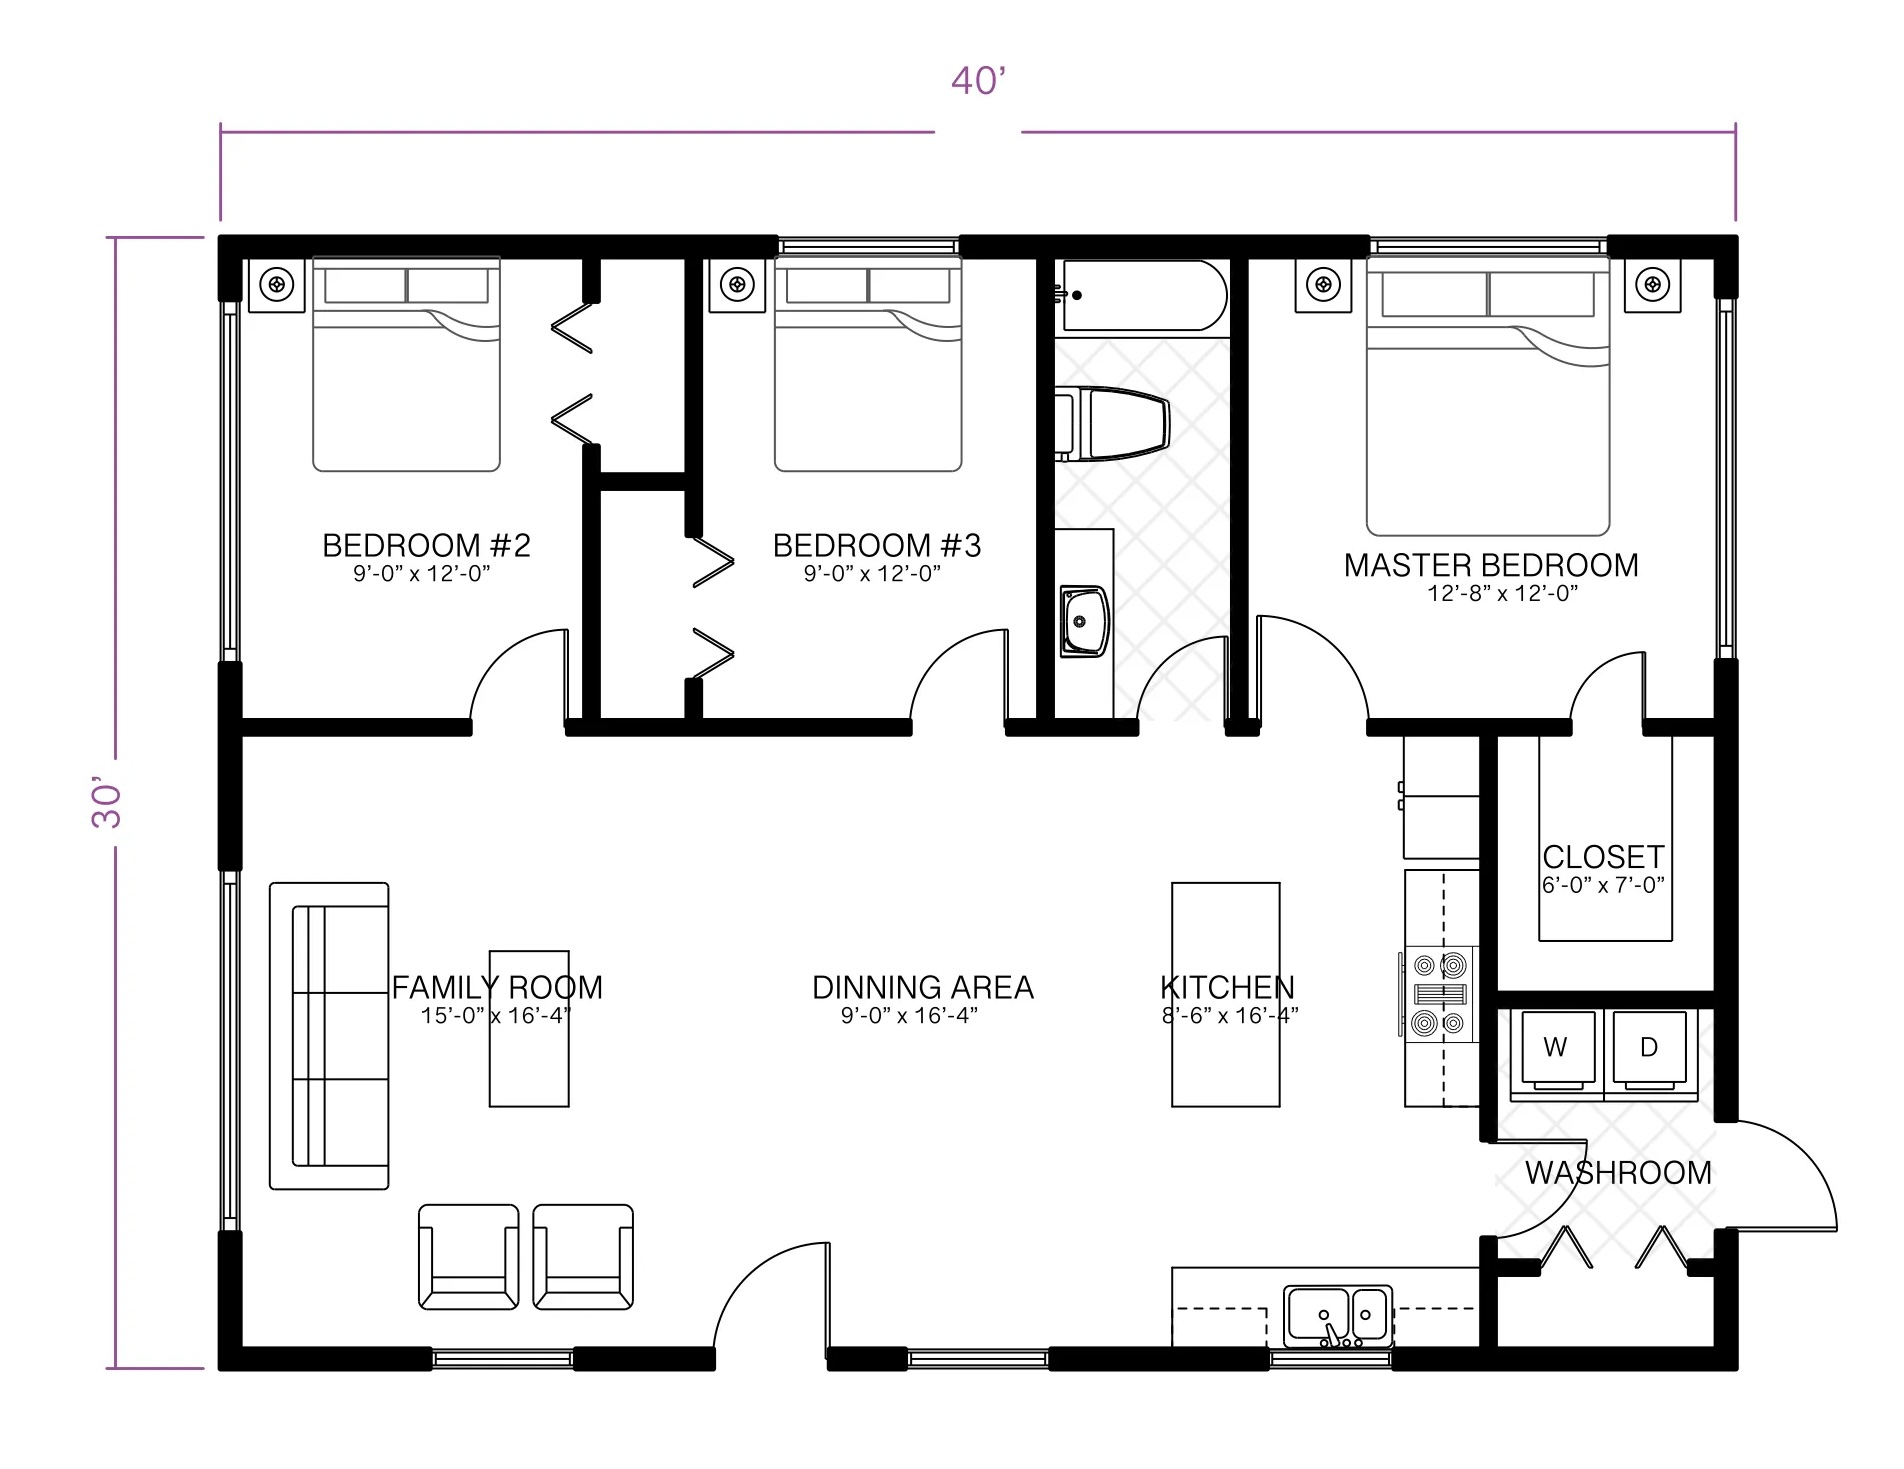

Saved: /content/floorplan_parser_output/floor copy.jpg | original size: (1904, 1469)


In [5]:
from google.colab import files
from IPython.display import display
from PIL import Image

uploaded = files.upload()  # choose one PNG, JPG, or JPEG floor-plan image
assert uploaded, 'Please upload a floor-plan image.'
image_name, image_bytes = next(iter(uploaded.items()))
image_path = WORKDIR / image_name
image_path.write_bytes(image_bytes)
source_image = Image.open(image_path).convert('RGB')
display(source_image)
print('Saved:', image_path, '| original size:', source_image.size)

In [6]:
!pip install svgpathtools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 4.1 MB/s eta 0:00:00


## 3. Load the published CubiCasa5K model

The original project targets an older PyTorch release. This cell keeps its model architecture and checkpoint, but uses the current Colab device API.

In [10]:
import matplotlib
import matplotlib.cm as cm

# --- Global Patch for Matplotlib API Change ---
# Fix for AttributeError: module 'matplotlib.cm' has no attribute 'register_cmap'
def _patched_register_cmap(cmap=None, name=None, **kwargs):
    name = name or (cmap.name if hasattr(cmap, 'name') else None)
    if name:
        try:
            # Use the newer registry if available
            if hasattr(matplotlib, 'colormaps'):
                matplotlib.colormaps.register(cmap=cmap, name=name)
        except Exception:
            pass

if not hasattr(cm, 'register_cmap'):
    cm.register_cmap = _patched_register_cmap
# ----------------------------------------------

%cd /content/CubiCasa5k
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from floortrans.models import get_model
from floortrans.loaders import RotateNTurns
from floortrans.plotting import discrete_cmap, polygons_to_image
from floortrans.post_prosessing import split_prediction, get_polygons

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert device.type == 'cuda', 'Enable a GPU runtime in Colab before continuing.'
split = [21, 12, 11]
room_classes = ['Background', 'Outdoor', 'Wall', 'Kitchen', 'Living Room', 'Bed Room', 'Bath', 'Entry', 'Railing', 'Storage', 'Garage', 'Undefined']
icon_classes = ['No Icon', 'Window', 'Door', 'Closet', 'Electrical Appliance', 'Toilet', 'Sink', 'Sauna Bench', 'Fire Place', 'Bathtub', 'Chimney']

model = get_model('hg_furukawa_original', 51)
model.conv4_ = torch.nn.Conv2d(256, 44, bias=True, kernel_size=1)
model.upsample = torch.nn.ConvTranspose2d(44, 44, kernel_size=4, stride=4)
checkpoint = torch.load('model_best_val_loss_var.pkl', map_location=device)
model.load_state_dict(checkpoint['model_state'])
model.to(device).eval()
rot = RotateNTurns()
discrete_cmap()
print('Model loaded on', device)

/content/CubiCasa5k
Model loaded on cuda


## 4. Run CubiCasa5K parsing

For reliability and GPU memory use, the longest side is limited to 1,024 pixels, then padded to a multiple of 32. The result is mapped back to that processed image size.

Saved segmentation masks: /content/floorplan_parser_output/cubicasa5k_prediction.npz


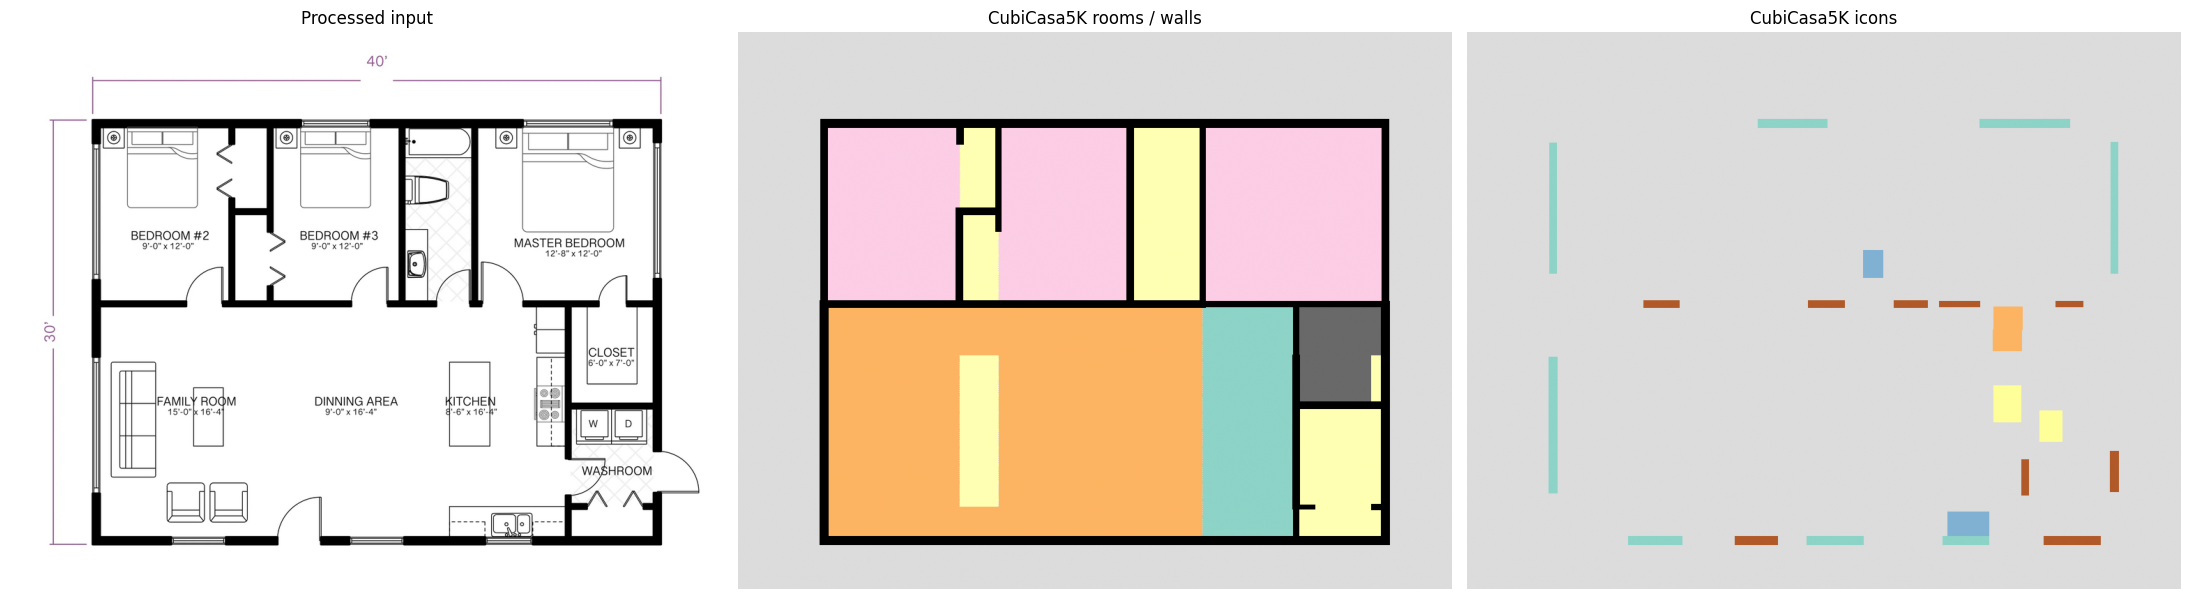

In [12]:
import scipy.stats as stats
import floortrans.post_prosessing

# --- Patch for Scipy 1.11+ compatibility in floortrans ---
# The library uses stats.mode(x).mode[0], which fails in new Scipy versions.
original_mode = stats.mode
def _patched_mode(*args, **kwargs):
    res = original_mode(*args, **kwargs)
    # If the result is a scalar-like object with a .mode attribute,
    # ensure .mode is treatable as a sequence for the library's [0] indexing.
    if hasattr(res, 'mode'):
        mode_val = res.mode
        if np.isscalar(mode_val):
            # Wrap in a list so mode[0] works
            class LegacyMode:
                def __init__(self, m):
                    self.mode = [m]
            return LegacyMode(mode_val)
    return res

# Apply patch to the module namespace where it is used
floortrans.post_prosessing.stats.mode = _patched_mode
# --------------------------------------------------------

MAX_SIDE = 1024
img = source_image.copy()
scale = min(1.0, MAX_SIDE / max(img.size))
resized_size = (round(img.width * scale), round(img.height * scale))
img = img.resize(resized_size, Image.Resampling.LANCZOS)
padded_w = (img.width + 31) // 32 * 32
padded_h = (img.height + 31) // 32 * 32
canvas = Image.new('RGB', (padded_w, padded_h), 'white')
canvas.paste(img, (0, 0))
x = (np.asarray(canvas).astype(np.float32) / 255.0 - 0.5) * 2.0
image_tensor = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    predictions = []
    for forward, backward in [(0, 0), (1, -1), (2, 2), (-1, 1)]:
        pred = model(rot(image_tensor, 'tensor', forward))
        pred = rot(pred, 'tensor', backward)
        pred = rot(pred, 'points', backward)
        pred = F.interpolate(pred, size=(padded_h, padded_w), mode='bilinear', align_corners=True)
        predictions.append(pred)
    prediction = torch.stack(predictions).mean(0).cpu()

heatmaps, rooms, icons = split_prediction(prediction, (padded_h, padded_w), split)
polygons, types, room_polygons, room_types = get_polygons((heatmaps, rooms, icons), 0.2, [1, 2])
room_seg, icon_seg = polygons_to_image(polygons, types, room_polygons, room_types, padded_h, padded_w)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
axes[0].imshow(canvas); axes[0].set_title('Processed input'); axes[0].axis('off')
axes[1].imshow(room_seg, cmap='rooms', vmin=0, vmax=10.9); axes[1].set_title('CubiCasa5K rooms / walls'); axes[1].axis('off')
axes[2].imshow(icon_seg, cmap='icons', vmin=0, vmax=10.9); axes[2].set_title('CubiCasa5K icons'); axes[2].axis('off')
plt.tight_layout()

np.savez_compressed(WORKDIR / 'cubicasa5k_prediction.npz', room_seg=room_seg, icon_seg=icon_seg)
print('Saved segmentation masks:', WORKDIR / 'cubicasa5k_prediction.npz')

In [21]:
import svgwrite
from shapely.geometry import Polygon, MultiPolygon

def save_as_cubicasa_svg(output_path, room_polys, room_classes_meta, icon_polys, icon_classes_meta, width, height):
    dwg = svgwrite.Drawing(output_path, size=(width, height), profile='full')

    def add_geom_to_group(group, geom, class_label):
        """Helper to extract points from Shapely geoms and add to SVG group"""
        if isinstance(geom, Polygon):
            pts = [(float(p[0]), float(p[1])) for p in geom.exterior.coords]
            group.add(dwg.polygon(points=pts, class_=class_label))
        elif isinstance(geom, MultiPolygon):
            for sub_poly in geom.geoms:
                pts = [(float(p[0]), float(p[1])) for p in sub_poly.exterior.coords]
                group.add(dwg.polygon(points=pts, class_=class_label))

    # CubiGraph5K expects individual <g> tags for each room inside the main Space group
    main_space_group = dwg.add(dwg.g(class_='Space'))
    for i, (geom, meta) in enumerate(zip(room_polys, room_classes_meta)):
        if not geom.is_empty:
            class_name = room_classes[meta['class']]
            # Wrap each individual room in its own group with the Space class
            room_group = main_space_group.add(dwg.g(class_=f'Space {class_name}'))
            add_geom_to_group(room_group, geom, class_name)

    # Group for doors/windows (Thresholds)
    threshold_group = dwg.add(dwg.g(class_='Threshold'))
    for poly_data, meta in zip(icon_polys, icon_classes_meta):
        class_name = icon_classes[meta['class']]
        if class_name in ['Door', 'Window']:
            # Each door/window also gets its own group
            door_group = threshold_group.add(dwg.g(class_=f'Threshold {class_name}'))
            if isinstance(poly_data, np.ndarray):
                flat_pts = poly_data.reshape(-1, 2)
                pts = [(float(p[0]), float(p[1])) for p in flat_pts]
                door_group.add(dwg.polygon(points=pts, class_=class_name))
            else:
                add_geom_to_group(door_group, poly_data, class_name)

    dwg.save()
    print(f'Generated CubiCasa-style SVG with grouped rooms: {output_path}')

# Generate the SVG using the data from the prediction cell
svg_model_path = WORKDIR / 'model.svg'
save_as_cubicasa_svg(
    svg_model_path,
    room_polygons, room_types,
    polygons, types,
    padded_w, padded_h
)

# Set the svg_path variable for the next section
svg_path = svg_model_path

Generated CubiCasa-style SVG with grouped rooms: /content/floorplan_parser_output/model.svg


## 5. CubiGraph5K — upload an annotated `model.svg`

Upload the `model.svg` for a CubiCasa5K dataset example. The SVG must contain `g class="Space"` room groups and `g class="Threshold"` door groups. CubiGraph labels edges as `1 = adjacent` and `2 = connected through a door`.

Processing SVG: /content/floorplan_parser_output/model.svg

Adjacency list generated:
{
  "Space_1": {
    "Kitchen_1": 1,
    "Room_1": 1,
    "Storage_1": 1
  },
  "Kitchen_1": {
    "Space_1": 1,
    "Room_1": 1,
    "Storage_1": 1
  },
  "Room_1": {
    "Space_1": 1,
    "Kitchen_1": 1,
    "Room_2": 1,
    "Storage_1": 2,
    "Undefined_1": 1
  },
  "Room_2": {
    "Room_1": 1,
    "Undefined_1": 1
  },
  "Storage_1": {
    "Space_1": 1,
    "Kitchen_1": 1,
    "Room_1": 2
  },
  "Undefined_1": {
    "Room_1": 1,
    "Room_2": 1
  }
}


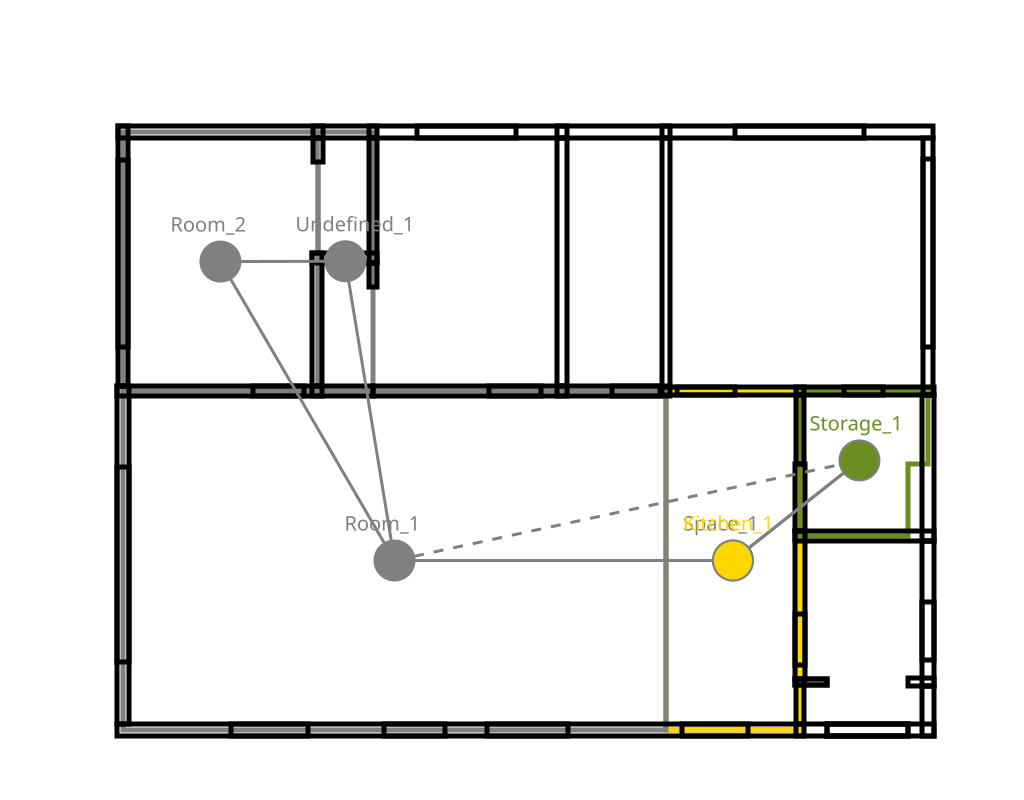


Saved graph visualization: /content/floorplan_parser_output/cubigraph_relations.svg
Saved adjacency data: /content/floorplan_parser_output/cubigraph_adjacency.json


In [22]:
import sys
sys.path.insert(0, '/content/CubiGraph5K/src')
from bs4 import BeautifulSoup
import plan
from plan import Plan, Room
from IPython.display import SVG, display
import json
import warnings
from bs4 import XMLParsedAsHTMLWarning
from shapely.geometry import Polygon

# --- Patch CubiGraph5K to handle our SVG format ---
# The library expects class=['Space', 'RoomType']. We provide class=['RoomType'].
# Also map CubiCasa5K room names to CubiGraph5K internal names.
room_name_fix = {
    'Living Room': 'LivingRoom',
    'Bed Room': 'Bedroom',
    'Bath': 'Bathroom',
    'Entry': 'Entryway',
    'Storage': 'Storage'
}

def _patched_room_init(self, svg_space_group, room_type_count):
    # Initialize required attributes that the library expects
    self.adjacent_doors = set()
    self.points = plan.get_points_from_svg_group(svg_space_group)

    # Calculate center point for visualization
    if len(self.points) >= 3:
        centroid = Polygon(self.points).centroid
        self.center_point = (centroid.x, centroid.y)
    else:
        self.center_point = (0, 0)

    cls_list = svg_space_group.attrs.get('class', [])
    # Pick the room type from the list, default to 'Undefined'
    raw_type = cls_list[-1] if cls_list else 'Undefined'
    self.type = room_name_fix.get(raw_type, raw_type)

    if self.type not in room_type_count:
        room_type_count[self.type] = 0
    self.name = '{}_{}'.format(self.type, room_type_count[self.type] + 1)
    room_type_count[self.type] += 1

Room.__init__ = _patched_room_init
# --------------------------------------------------

print(f"Processing SVG: {svg_path}")
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

with open(svg_path, 'r', encoding='utf-8') as f:
    soup = BeautifulSoup(f, 'lxml')

# CubiGraph5K looks for 'g' tags with class 'Space'
plan_obj = Plan(soup.find('svg'))
plan_obj.generate_room_relation()
adjacency = plan_obj.get_adjacency_list()

print("\nAdjacency list generated:")
print(json.dumps(adjacency, indent=2))

graph_svg_path = WORKDIR / 'cubigraph_relations.svg'
graph_svg_path.write_text(str(plan_obj.generate_relation_svg()), encoding='utf-8')
graph_json_path = WORKDIR / 'cubigraph_adjacency.json'
graph_json_path.write_text(json.dumps(adjacency, indent=2), encoding='utf-8')

display(SVG(filename=str(graph_svg_path)))
print('\nSaved graph visualization:', graph_svg_path)
print('Saved adjacency data:', graph_json_path)

## 6. Download outputs

In [ ]:
archive = shutil.make_archive('/content/floorplan_parser_output', 'zip', WORKDIR)
files.download(archive)